1. Import data Olist

In [ ]:
# cài gdown
!pip install -q gdown

In [ ]:
# download folder Olist
import gdown
folder_url = "https://drive.google.com/drive/folders/1BnELW6VDaqa-yUkLsArstDrYMTfLTUgO"
gdown.download_folder(
    url=folder_url,
    quiet=False,
    use_cookies=False)

Retrieving folder contents


Processing file 1bHbtTdQ5NR7tBb3RDy5S8G_nV3ASx00k olist_customers_dataset.csv
Processing file 13LQfniQvJI1LjN229ymPpRMuGFeJc01s olist_geolocation_dataset.csv
Processing file 1z1GOHLjSw1q4wihWUXKkXMqWTAiOjNaA olist_order_items_dataset.csv
Processing file 1wnLQt5xgopfTzMe4TkAZYRNYBwqFWTO4 olist_order_payments_dataset.csv
Processing file 1rcWQTKexHfwR4kvbBeCrHbwuFNiCZv_B olist_order_reviews_dataset.csv
Processing file 1fa5A-wqYDwKK1P5Be2SLGiy6Ub-130__ olist_orders_dataset.csv
Processing file 1FHm_rNEG3k-uld9ysm82DLtjwf-ivnWT olist_products_dataset.csv
Processing file 1BqJCvy8cZagZDzdzkVjJ0q8bPS2HYQ1x olist_sellers_dataset.csv
Processing file 1kV-lkd8AGdK_4v6azUp8mCb5_O2s2VqN product_category_name_translation.csv


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1bHbtTdQ5NR7tBb3RDy5S8G_nV3ASx00k
To: /content/Olist/olist_customers_dataset.csv
100%|██████████| 8.66M/8.66M [00:00<00:00, 33.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=13LQfniQvJI1LjN229ymPpRMuGFeJc01s
To: /content/Olist/olist_geolocation_dataset.csv
100%|██████████| 47.0M/47.0M [00:00<00:00, 61.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1z1GOHLjSw1q4wihWUXKkXMqWTAiOjNaA
To: /content/Olist/olist_order_items_dataset.csv
100%|██████████| 14.5M/14.5M [00:00<00:00, 32.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1wnLQt5xgopfTzMe4TkAZYRNYBwqFWTO4
To: /content/Olist/olist_order_payments_dataset.csv
100%|██████████| 5.73M/5.73M [00:00<00:00, 53.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1rcWQTKexHfwR4kvbBeCrHbwuFNiCZv_B
To: /content/Olist/olist_order_reviews_dataset.csv
100%|

['/content/Olist/olist_customers_dataset.csv',
 '/content/Olist/olist_geolocation_dataset.csv',
 '/content/Olist/olist_order_items_dataset.csv',
 '/content/Olist/olist_order_payments_dataset.csv',
 '/content/Olist/olist_order_reviews_dataset.csv',
 '/content/Olist/olist_orders_dataset.csv',
 '/content/Olist/olist_products_dataset.csv',
 '/content/Olist/olist_sellers_dataset.csv',
 '/content/Olist/product_category_name_translation.csv']

In [ ]:
import os
for root, dirs, files in os.walk("."):
    for f in files:
        print(os.path.join(root, f))

./.config/.last_opt_in_prompt.yaml
./.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
./.config/active_config
./.config/default_configs.db
./.config/gce
./.config/config_sentinel
./.config/.last_update_check.json
./.config/.last_survey_prompt.yaml
./.config/configurations/config_default
./.config/logs/2026.06.04/13.32.39.344962.log
./.config/logs/2026.06.04/13.32.18.735754.log
./.config/logs/2026.06.04/13.32.02.654775.log
./.config/logs/2026.06.04/13.32.21.210570.log
./.config/logs/2026.06.04/13.32.38.346437.log
./.config/logs/2026.06.04/13.31.42.499627.log
./Olist/product_category_name_translation.csv
./Olist/olist_order_items_dataset.csv
./Olist/olist_geolocation_dataset.csv
./Olist/olist_sellers_dataset.csv
./Olist/olist_customers_dataset.csv
./Olist/olist_order_payments_dataset.csv
./Olist/olist_orders_dataset.csv
./Olist/olist_order_reviews_dataset.csv
./Olist/olist_products_dataset.csv
./sample_data/anscombe.json
./sample_data/README.md
./sample_data/califor

In [ ]:
import pandas as pd
import numpy as np
import datetime as dt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import seaborn as sns
from matplotlib import pyplot as plt

In [83]:
# Theme chung
sns.set_theme(style="whitegrid")

# BẢNG MÀU
MAIN_COLOR = '#114B5F'
SECONDARY_COLOR = '#7FA5A3'
LIGHT_COLOR = '#DCE7E6'

# Palette mặc định cho tất cả chart
sns.set_palette([MAIN_COLOR])

# Font & size
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['font.size'] = 10

In [ ]:
# load dữ liệu
customers = pd.read_csv('/content/Olist/olist_customers_dataset.csv')
orders = pd.read_csv('/content/Olist/olist_orders_dataset.csv')
order_items = pd.read_csv('/content/Olist/olist_order_items_dataset.csv')
payments = pd.read_csv('/content/Olist/olist_order_payments_dataset.csv')
products = pd.read_csv('/content/Olist/olist_products_dataset.csv')
categories = pd.read_csv('/content/Olist/product_category_name_translation.csv')

2. EDA dữ liệu

In [ ]:
# bảng customers: check missing & duplicate
customers.info()
customers.isnull().sum()
customers.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


np.int64(0)

In [ ]:
# tạo bảng dim_customer
dim_customer = (
    customers[
        [
            'customer_unique_id',
            'customer_id',
            'customer_city',
            'customer_state'
        ]
    ]
    .drop_duplicates()
)

print(dim_customer.shape)
dim_customer.head()

(99441, 4)


,customer_unique_id,customer_id,customer_city,customer_state
0,861eff4711a542e4b93843c6dd7febb0,06b8999e2fba1a1fbc88172c00ba8bc7,franca,SP
1,290c77bc529b7ac935b93aa66c333dc3,18955e83d337fd6b2def6b18a428ac77,sao bernardo do campo,SP
2,060e732b5b29e8181a18229c7b0b2b5e,4e7b3e00288586ebd08712fdd0374a03,sao paulo,SP
3,259dac757896d24d7702b9acbbff3f3c,b2b6027bc5c5109e529d4dc6358b12c3,mogi das cruzes,SP
4,345ecd01c38d18a9036ed96c73b8d066,4f2d8ab171c80ec8364f7c12e35b23ad,campinas,SP


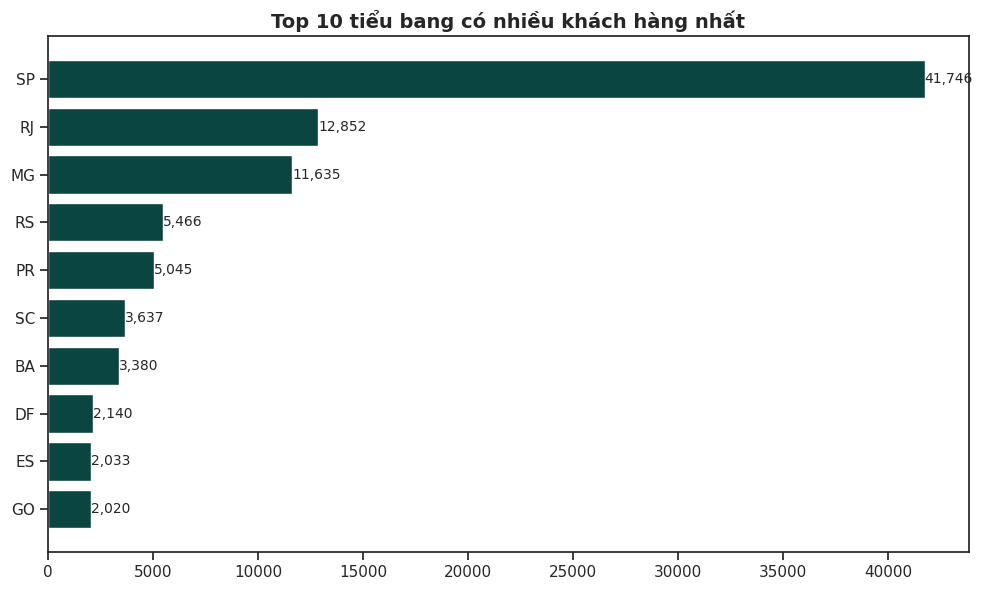

In [ ]:
# Top bang (state) có nhiều khách hàng nhất
state_count = (
    dim_customer['customer_state']
    .value_counts()
    .head(10)
    .sort_values()
)

sns.set_style("ticks")

fig, ax = plt.subplots(figsize=(10,6))

bars = ax.barh(
    state_count.index,
    state_count.values,
    color=MAIN_COLOR
)

ax.set_title(
    'Top 10 tiểu bang có nhiều khách hàng nhất'
)

for bar in bars:
    ax.text(
        bar.get_width(),
        bar.get_y()+bar.get_height()/2,
        f'{int(bar.get_width()):,}',
        va='center'
    )

sns.set_style("ticks")

plt.tight_layout()
plt.show()

In [ ]:
# bảng orders: check missing & chuyển data datetime
orders.isnull().sum()
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp'])

# chỉ giữ đơn giao thành công
orders = orders[orders['order_status'] == 'delivered'].copy()

#taọ bảng order mới chỉ giữ date mua hàng
orders = (
    orders[
        [
            'order_id',
            'customer_id',
            'order_status',
            'order_purchase_timestamp'
        ]
    ]
)
orders.info()
orders.head()

<class 'pandas.core.frame.DataFrame'>
Index: 96478 entries, 0 to 99440
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   order_id                  96478 non-null  object        
 1   customer_id               96478 non-null  object        
 2   order_status              96478 non-null  object        
 3   order_purchase_timestamp  96478 non-null  datetime64[ns]
dtypes: datetime64[ns](1), object(3)
memory usage: 3.7+ MB


,order_id,customer_id,order_status,order_purchase_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:00


In [ ]:
# nhóm dữ liệu
order_items_agg = (
    order_items
    .groupby('order_id')
    .agg(
        total_price=('price', 'sum'),
        total_freight=('freight_value', 'sum'),
        n_items=('order_item_id', 'count'),
        unique_products=('product_id','nunique')
    )
    .reset_index()
)
payments_agg = (
    payments
    .groupby('order_id')
    .agg(
        payment_value=('payment_value', 'sum'),
        payment_installments=('payment_installments', 'max')
    )
    .reset_index()
)

In [ ]:
# bảng order_items: check missing & duplicate
order_items.info()
order_items.isnull().sum()
order_items.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


np.int64(0)

In [ ]:
# bảng payments: check missing & duplicate
payments.info()
payments.isnull().sum()
payments.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


np.int64(0)

In [ ]:
# tạo bảng fact_sales
fact_sales = (
    orders
    .merge(
        customers[['customer_id','customer_unique_id']],
        on='customer_id',
        how='left'
    )
    .merge(
        order_items_agg,
        on='order_id',
        how='left'
    )
    .merge(
        payments_agg,
        on='order_id',
        how='left'
    )
)

fact_sales.head()

,order_id,customer_id,order_status,order_purchase_timestamp,customer_unique_id,total_price,total_freight,n_items,unique_products,payment_value,payment_installments
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:00,7c396fd4830fd04220f754e42b4e5bff,29.99,8.72,1,1,38.71,1.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:00,af07308b275d755c9edb36a90c618231,118.70,22.76,1,1,141.46,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:00,3a653a41f6f9fc3d2a113cf8398680e8,159.90,19.22,1,1,179.12,3.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:00,7c142cf63193a1473d2e66489a9ae977,45.00,27.20,1,1,72.20,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:00,72632f0f9dd73dfee390c9b22eb56dd6,19.90,8.72,1,1,28.62,1.0


/tmp/ipykernel_17961/3512604764.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M')


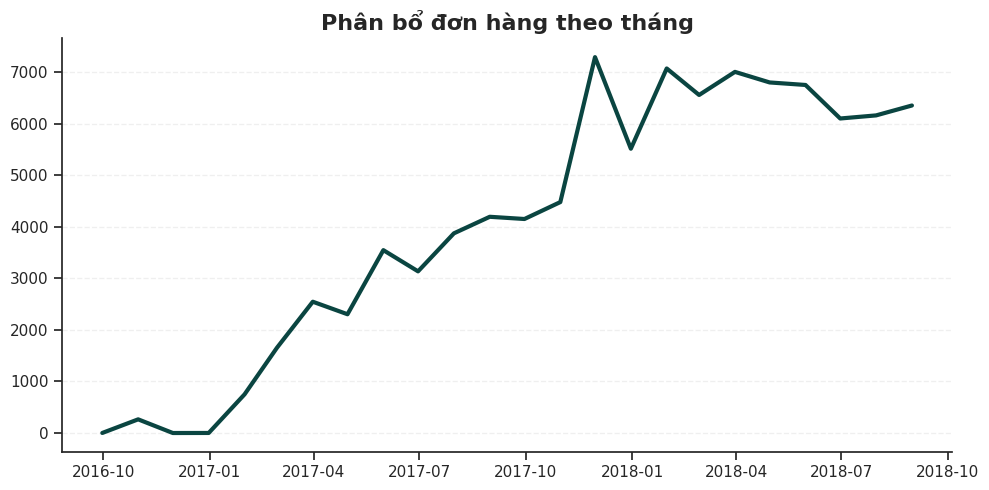

In [ ]:
# Phân bố đơn hàng theo thời gian
monthly_orders = (
    fact_sales
    .set_index('order_purchase_timestamp')
    .resample('M')
    .size()
)

sns.set_style("ticks")

fig, ax = plt.subplots(figsize=(10,5))

ax.plot(
    monthly_orders.index,
    monthly_orders.values,
    color="#0A4541",
    linewidth=3
)

ax.set_title(
    "Phân bổ đơn hàng theo tháng",
    fontsize=16,
    fontweight='bold'
)

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# tạo bảng fact_order_detail
fact_order_detail = (
    orders
    .merge(
        customers[
            ['customer_id',
             'customer_unique_id']
        ],
        on='customer_id',
        how='left'
    )
    .merge(
        order_items,
        on='order_id',
        how='left'
    )
    .merge(
        products[
            ['product_id',
             'product_category_name']
        ],
        on='product_id',
        how='left'
    )
    .merge(
        categories,
        on='product_category_name',
        how='left'
    )
)
fact_order_detail = fact_order_detail[
    [
        'order_id',
        'customer_unique_id',
        'order_purchase_timestamp',
        'product_id',
        'product_category_name',
        'product_category_name_english',
        'price',
        'freight_value'
    ]
]
fact_order_detail.head()

,order_id,customer_unique_id,order_purchase_timestamp,product_id,product_category_name,product_category_name_english,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:00,87285b34884572647811a353c7ac498a,utilidades_domesticas,housewares,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,2018-07-24 20:41:00,595fac2a385ac33a80bd5114aec74eb8,perfumaria,perfumery,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08 08:38:00,aa4383b373c6aca5d8797843e5594415,automotivo,auto,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,2017-11-18 19:28:00,d0b61bfb1de832b15ba9d266ca96e5b0,pet_shop,pet_shop,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13 21:18:00,65266b2da20d04dbe00c5c2d3bb7859e,papelaria,stationery,19.90,8.72


3. Tính RFM

In [ ]:
fact_sales.order_purchase_timestamp.max()

Timestamp('2018-08-29 15:00:00')

In [ ]:
snapshot_date = pd.to_datetime('2018-08-31')

In [ ]:
olist_rfm = (
    fact_sales
    .groupby('customer_unique_id')
    .agg(
        Recency=(
            'order_purchase_timestamp',
            lambda x: (snapshot_date - x.max()).days
        ),
        Frequency=('order_id', 'nunique'),
        Monetary=('payment_value', 'sum')
    )
    .reset_index()
)

In [ ]:
olist_rfm

,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
2,0000f46a3911fa3c0805444483337064,538,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,322,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,289,1,196.89
...,...,...,...,...
93353,fffcf5a5ff07b0908bd4e2dbc735a684,448,1,2067.42
93354,fffea47cd6d3cc0a88bd621562a9d061,263,1,84.58
93355,ffff371b4d645b6ecea244b27531430a,569,1,112.46
93356,ffff5962728ec6157033ef9805bacc48,120,1,133.69


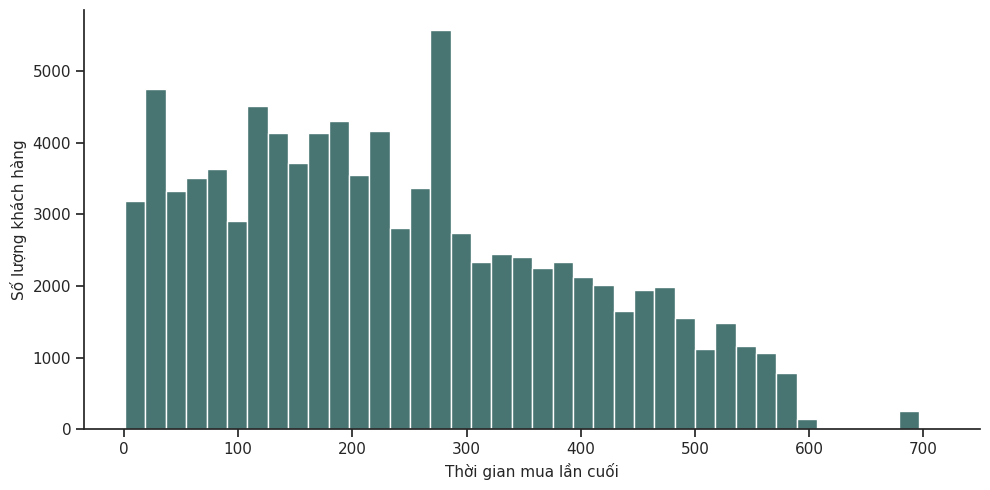

In [ ]:
# Phân phối Recency
fig, ax = plt.subplots(figsize=(10,5))

sns.histplot(
    olist_rfm['Recency'],
    bins=40,
    color=MAIN_COLOR,
    edgecolor='white',
    ax=ax
)

ax.set_xlabel('Thời gian mua lần cuối')
ax.set_ylabel('Số lượng khách hàng')

sns.despine()
plt.tight_layout()
plt.show()

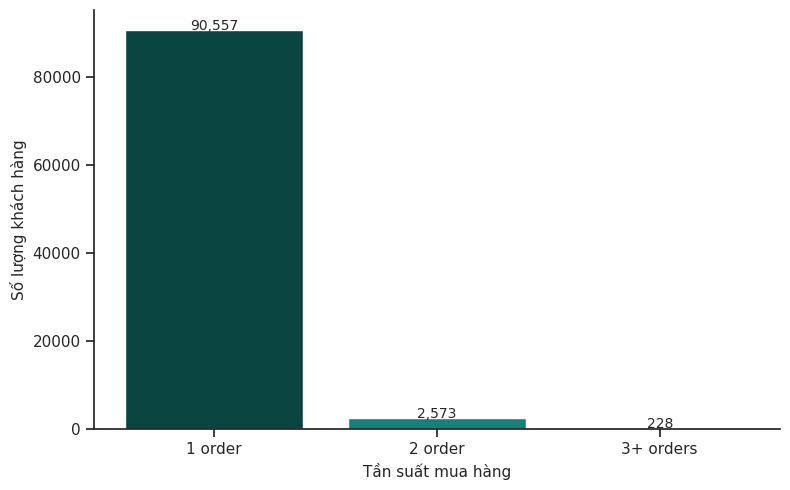

In [ ]:
# Phân phối Frequency
freq_group = pd.Series(
    np.where(
        olist_rfm['Frequency'] >= 3,
        '3+ orders',
        olist_rfm['Frequency'].astype(str) + ' order'
    )
)

freq_dist = (
    freq_group
    .value_counts()
    .reindex(['1 order','2 order','3+ orders'])
)

fig, ax = plt.subplots(figsize=(8,5))

bars = ax.bar(
    freq_dist.index,
    freq_dist.values,
    color=[MAIN_COLOR, '#16817A', '#5CB8B2']
)

ax.set_xlabel('Tần suất mua hàng')
ax.set_ylabel('Số lượng khách hàng')

for bar in bars:
    ax.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f'{int(bar.get_height()):,}',
        ha='center'
    )

sns.despine()
plt.tight_layout()
plt.show()

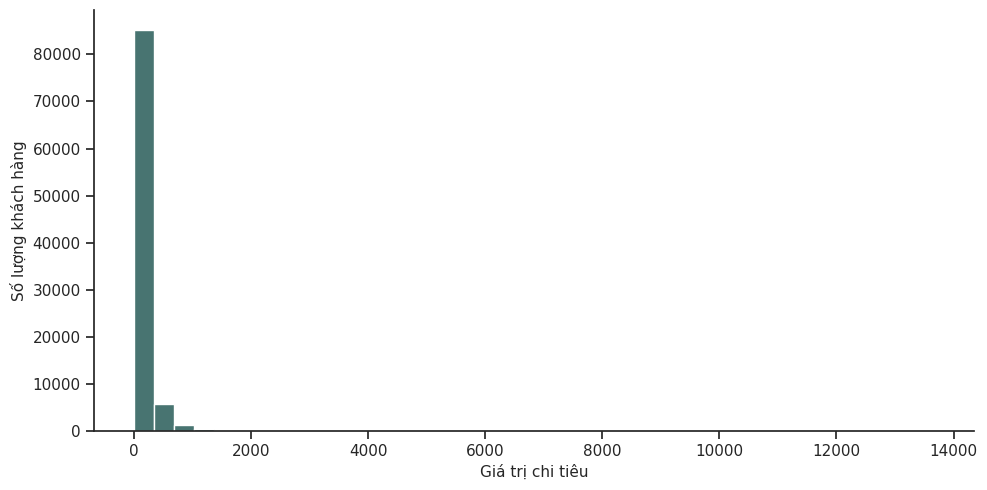

In [ ]:
# Phân phối Monetary
fig, ax = plt.subplots(figsize=(10,5))

sns.histplot(
    olist_rfm['Monetary'],
    bins=40,
    color=MAIN_COLOR,
    edgecolor='white',
    ax=ax
)

ax.set_xlabel('Giá trị chi tiêu')
ax.set_ylabel('Số lượng khách hàng')

sns.despine()
plt.tight_layout()
plt.show()

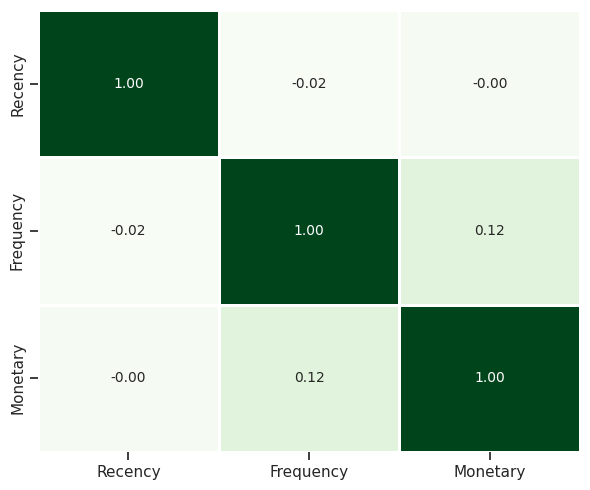

In [ ]:
# Correlation Heatmap
corr = olist_rfm[
    ['Recency','Frequency','Monetary']
].corr()

fig, ax = plt.subplots(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap='Greens',
    fmt='.2f',
    linewidths=1,
    cbar=False,
    ax=ax
)

plt.tight_layout()
plt.show()

In [ ]:
feature = olist_rfm[['Recency', 'Frequency', 'Monetary']]

_scaler = StandardScaler()
scaled_df = _scaler.fit_transform(feature)

In [ ]:
scaled_df

array([[-0.82886065, -0.1598294 , -0.1029416 ],
       [-0.80920065, -0.1598294 , -0.60980644],
       [ 1.96285823, -0.1598294 , -0.34897276],
       ...,
       [ 2.16601149, -0.1598294 , -0.23302704],
       [-0.776434  , -0.1598294 , -0.13921883],
       [ 1.61553171, -0.1598294 , -0.41375036]])

In [ ]:
# Elbow Method and silhouette scores to find the optimal number of clusters
sse = []
silhouette_scores = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_df)
    sse.append(model.inertia_)
    silhouette_scores.append(
        silhouette_score(
            scaled_df,
            model.labels_
        )
    )

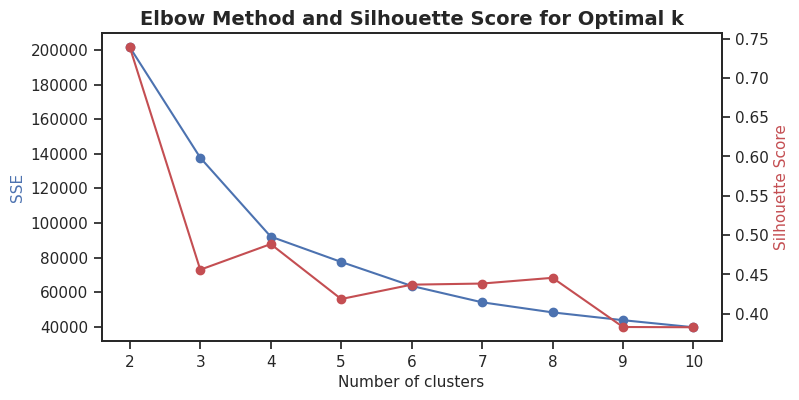

In [ ]:
# Plot
fig, ax1 = plt.subplots(figsize=(8, 4))

ax2 = ax1.twinx()
ax1.plot(range(2, 11), sse, "bo-")
ax2.plot(range(2, 11), silhouette_scores, "ro-")

ax1.set_xlabel("Number of clusters")
ax1.set_ylabel("SSE", color="b")
ax2.set_ylabel("Silhouette Score", color="r")

plt.title("Elbow Method and Silhouette Score for Optimal k")
plt.show()

In [ ]:
# retrain model với k=6
kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

kmeans.fit(scaled_df)

KMeans(n_clusters=6, n_init=10, random_state=42)

In [ ]:
kmeans.labels_

array([0, 0, 1, ..., 1, 0, 1], dtype=int32)

In [ ]:
olist_rfm['clusters'] = kmeans.labels_

In [ ]:
olist_rfm

,customer_unique_id,Recency,Frequency,Monetary,clusters
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,0
2,0000f46a3911fa3c0805444483337064,538,1,86.22,1
3,0000f6ccb0745a6a4b88665a16c9f078,322,1,43.62,5
4,0004aac84e0df4da2b147fca70cf8255,289,1,196.89,5
...,...,...,...,...,...
93353,fffcf5a5ff07b0908bd4e2dbc735a684,448,1,2067.42,4
93354,fffea47cd6d3cc0a88bd621562a9d061,263,1,84.58,5
93355,ffff371b4d645b6ecea244b27531430a,569,1,112.46,1
93356,ffff5962728ec6157033ef9805bacc48,120,1,133.69,0


In [ ]:
olist_rfm.clusters.value_counts()

,count
clusters,
0,33066
5,32495
1,20431
3,4079
2,2778
4,509


In [ ]:
olist_rfm.groupby('clusters')[
    ['Recency','Frequency','Monetary']
].mean().round(2)

,Recency,Frequency,Monetary
clusters,,,
0,87.66,1.00,125.39
1,459.42,1.00,126.30
2,220.97,2.11,291.81
3,227.24,1.00,712.04
4,235.79,1.05,2091.18
5,255.98,1.00,120.52


In [ ]:
olist_rfm.pivot_table(
    index='clusters',
    values=['Recency', 'Monetary', 'Frequency'],
    aggfunc=['mean', 'std']
)

mean                                std                        
         Frequency     Monetary     Recency Frequency    Monetary     Recency
clusters                                                                     
0         1.000000   125.392914   87.660648  0.000000   85.978674   49.667886
1         1.000000   126.303669  459.419559  0.000000   93.744493   68.588865
2         2.113751   291.806944  220.972642  0.504233  228.623289  143.678020
3         1.000000   712.041677  227.241481  0.000000  237.774689  139.206459
4         1.051081  2091.181061  235.791749  0.253604  956.718493  159.392350
5         1.000000   120.518251  255.982890  0.000000   81.596668   51.480307

In [ ]:
olist_rfm['Frequency'].describe()

,Frequency
count,93358.000000
mean,1.033420
std,0.209097
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,15.000000


In [ ]:
olist_rfm['Frequency'].value_counts().head(20)

,count
Frequency,
1,90557
2,2573
3,181
4,28
5,9
6,5
7,3
9,1
15,1


In [ ]:
fact_order_detail = fact_order_detail.merge(
    olist_rfm[
        ['customer_unique_id', 'clusters']
    ],
    on='customer_unique_id',
    how='left'
)

In [ ]:
cluster_category = (
    fact_order_detail
    .groupby(
        [
            'clusters',
            'product_category_name_english'
        ]
    )
    .size()
    .reset_index(name='orders')
)

In [ ]:
cluster_category['clusters'].value_counts()

,count
clusters,
0,70
1,69
5,69
2,68
3,56
4,43


In [ ]:
# Đặt tên các phân khúc

# Profile trung bình của từng cluster
cluster_profile = (
    olist_rfm
    .groupby('clusters')
    [['Recency', 'Frequency', 'Monetary']]
    .mean()
)

# Mặc định
cluster_profile['segment_name'] = 'Khách phổ thông'

# 1. VIP
# Cluster có Monetary cao nhất

cluster_profile.loc[
    cluster_profile['Monetary'].idxmax(),
    'segment_name'
] = 'VIP'

# 2. Chi tiêu lớn
# Monetary cao thứ 2

remaining = cluster_profile[
    cluster_profile['segment_name'] == 'Khách phổ thông'
]

cluster_profile.loc[
    remaining['Monetary'].idxmax(),
    'segment_name'
] = 'Chi tiêu lớn'

# 3. Mua lặp lại
# Frequency cao nhất

remaining = cluster_profile[
    cluster_profile['segment_name'] == 'Khách phổ thông'
]

cluster_profile.loc[
    remaining['Frequency'].idxmax(),
    'segment_name'
] = 'Mua lặp lại'

# 4. Mới & Gần đây
# Recency thấp nhất

remaining = cluster_profile[
    cluster_profile['segment_name'] == 'Khách phổ thông'
]

cluster_profile.loc[
    remaining['Recency'].idxmin(),
    'segment_name'
] = 'Mới & Gần đây'

# 5. Ngủ đông
# Recency cao nhất

remaining = cluster_profile[
    cluster_profile['segment_name'] == 'Khách phổ thông'
]

cluster_profile.loc[
    remaining['Recency'].idxmax(),
    'segment_name'
] = 'Ngủ đông'

# Các cluster còn lại

cluster_profile['segment_name'] = (
    cluster_profile['segment_name']
    .fillna('Khách phổ thông')
)

# Map lại vào dataframe gốc

segment_map = (
    cluster_profile['segment_name']
    .to_dict()
)

olist_rfm['segment_name'] = (
    olist_rfm['clusters']
    .map(segment_map)
)

display(
    cluster_profile
    .sort_values('Monetary', ascending=False)
)

print(segment_map)

,Recency,Frequency,Monetary,segment_name
clusters,,,,
4,235.791749,1.051081,2091.181061,VIP
3,227.241481,1.000000,712.041677,Chi tiêu lớn
2,220.972642,2.113751,291.806944,Mua lặp lại
1,459.419559,1.000000,126.303669,Ngủ đông
0,87.660648,1.000000,125.392914,Mới & Gần đây
5,255.982890,1.000000,120.518251,Khách phổ thông


{0: 'Mới & Gần đây', 1: 'Ngủ đông', 2: 'Mua lặp lại', 3: 'Chi tiêu lớn', 4: 'VIP', 5: 'Khách phổ thông'}


In [ ]:
# Auto gen code from cluster id

cluster_profile['segment_code'] = (
    'C'
    + cluster_profile.index.astype(str)
)

cluster_profile['segment_label'] = (
    cluster_profile['segment_code']
    + ' - '
    + cluster_profile['segment_name']
)

In [ ]:
cluster_to_name = (
    cluster_profile['segment_name']
    .to_dict()
)

cluster_to_code = (
    cluster_profile['segment_code']
    .to_dict()
)

cluster_to_label = (
    cluster_profile['segment_label']
    .to_dict()
)

olist_rfm['segment_name'] = (
    olist_rfm['clusters']
    .map(cluster_to_name)
)

olist_rfm['segment_code'] = (
    olist_rfm['clusters']
    .map(cluster_to_code)
)

olist_rfm['segment_label'] = (
    olist_rfm['clusters']
    .map(cluster_to_label)
)

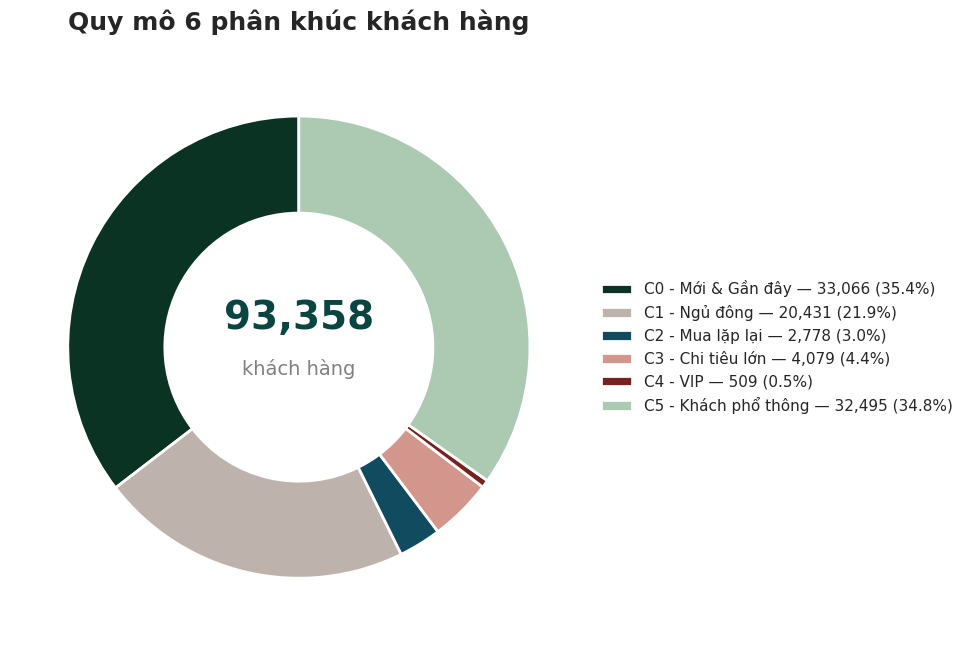

In [79]:
 # PHÂN KHÚC KHÁCH HÀNG
segment_size = (
    olist_rfm
    .groupby('segment_label')
    .size()
    .reindex(                                        # giữ thứ tự theo cluster_profile
        cluster_profile
        .sort_values('segment_code')['segment_label']
    )
)

colors = [
    '#0A3323',  # C0
    '#BEB3AC',  # C1
    '#114B5F',  # C2
    '#D3968C',  # C3
    '#78211E',  # C4
    '#ACCAB2',  # C5
]

fig, ax = plt.subplots(figsize=(9,7))

wedges, _ = ax.pie(
    segment_size,
    startangle=90,
    colors=colors,
    wedgeprops=dict(
        width=0.42,
        edgecolor='white',
        linewidth=2
    )
)

# Tổng KH ở giữa
ax.text(
    0,
    0.08,
    f"{segment_size.sum():,}",
    ha='center',
    fontsize=28,
    fontweight='bold',
    color='#0A4541'
)

ax.text(
    0,
    -0.12,
    "khách hàng",
    ha='center',
    fontsize=14,
    color='gray'
)

# Legend
labels = [
    f"{name} — {value:,} ({value/segment_size.sum():.1%})"
    for name, value in segment_size.items()
]

ax.legend(
    wedges,
    labels,
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=False,
    fontsize=11
)

plt.title(
    "Quy mô 6 phân khúc khách hàng",
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.show()

In [68]:
cluster_profile[['Recency', 'Frequency', 'Monetary', 'segment_code', 'segment_label']]\
    .sort_values('Monetary', ascending=False)\
    .style.background_gradient(cmap='Blues', subset=['Monetary', 'Frequency'])\
    .background_gradient(cmap='Reds_r', subset=['Recency'])

,Recency,Frequency,Monetary,segment_code,segment_label
clusters,,,,,
4,235.791749,1.051081,2091.181061,C4,C4 - VIP
3,227.241481,1.000000,712.041677,C3,C3 - Chi tiêu lớn
2,220.972642,2.113751,291.806944,C2,C2 - Mua lặp lại
1,459.419559,1.000000,126.303669,C1,C1 - Ngủ đông
0,87.660648,1.000000,125.392914,C0,C0 - Mới & Gần đây
5,255.982890,1.000000,120.518251,C5,C5 - Khách phổ thông


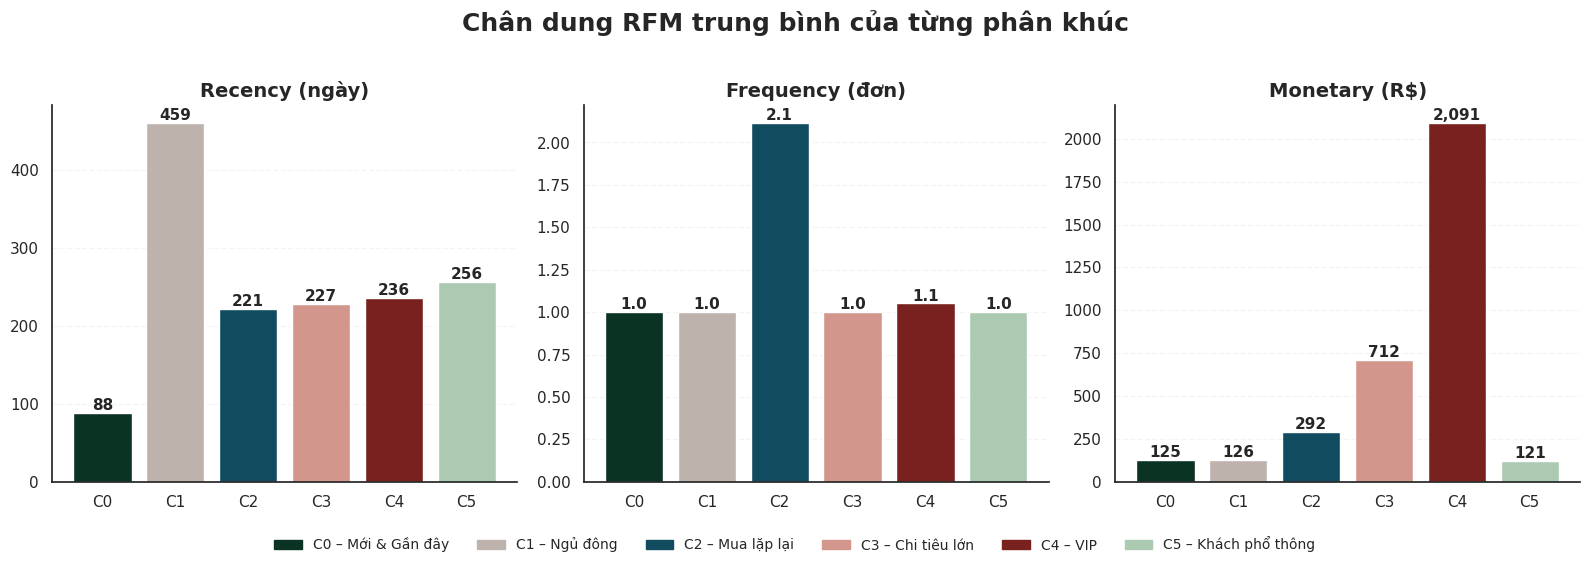

In [78]:
# RFM profile theo từng phân khúc — lấy từ cluster_profile (nguồn duy nhất)
segment_profile = (
    cluster_profile                          # đã có segment_code, segment_label, RFM mean
    .sort_values('segment_code')             # sắp xếp C0 → C5 để X-axis nhất quán
    .reset_index()
)

sns.set_style("white")

colors = [
    '#0A3323',  # C0
    '#BEB3AC',  # C1
    '#114B5F',  # C2
    '#D3968C',  # C3
    '#78211E',  # C4
    '#ACCAB2',  # C5
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['Recency', 'Frequency', 'Monetary']
titles  = ['Recency (ngày)', 'Frequency (đơn)', 'Monetary (R$)']

for ax, metric, title in zip(axes, metrics, titles):

    bars = ax.bar(
        segment_profile['segment_code'],     # X: C0, C1, C2... (đồng bộ với height)
        segment_profile[metric],             # Height: mean R/F/M đúng cluster
        color=colors[:len(segment_profile)]
    )

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.grid(axis='y', linestyle='--', alpha=0.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for bar in bars:
        value = bar.get_height()
        label = f'{value:.1f}' if metric == 'Frequency' else f'{value:,.0f}'
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value, label,
            ha='center', va='bottom',
            fontsize=11, fontweight='bold'
        )

# Legend để biết C0 → tên segment nào
legend_labels = (
    segment_profile['segment_code'] + ' – ' + segment_profile['segment_name']
).tolist()
handles = [plt.Rectangle((0,0),1,1, color=colors[i]) for i in range(len(segment_profile))]
fig.legend(handles, legend_labels, loc='lower center', ncol=len(segment_profile),
           fontsize=10, frameon=False, bbox_to_anchor=(0.5, -0.08))

fig.suptitle(
    'Chân dung RFM trung bình của từng phân khúc',
    fontsize=18, fontweight='bold', y=1.03
)

plt.tight_layout()
plt.show()

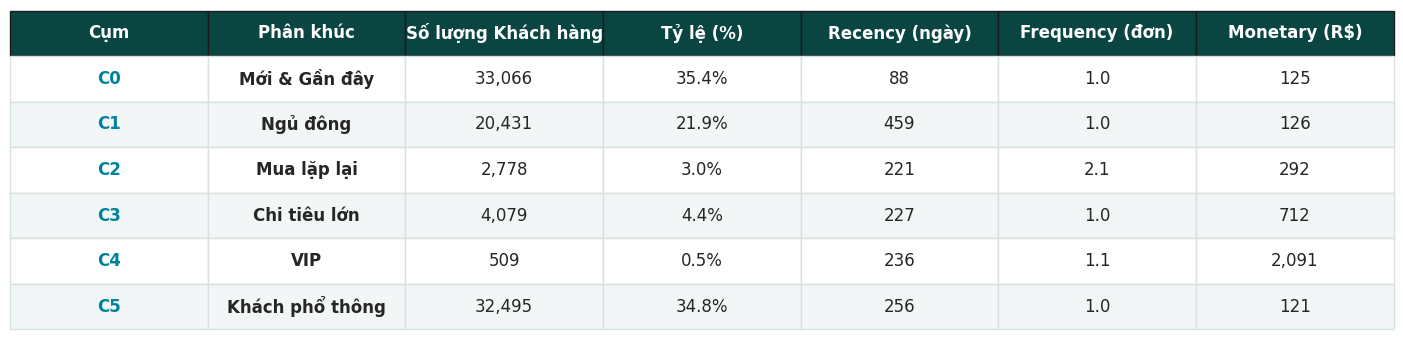

In [84]:
# 1. Tạo Segment Summary từ cluster_profile (nguồn duy nhất)
segment_summary = (
    olist_rfm
    .groupby('clusters')
    .agg(
        Customers=('customer_unique_id', 'count'),
        Recency=('Recency', 'mean'),
        Frequency=('Frequency', 'mean'),
        Monetary=('Monetary', 'mean')
    )
    .join(cluster_profile[['segment_code', 'segment_name', 'segment_label']])
    .sort_values('segment_code')
    .reset_index(drop=True)
)

# 2. Tính tỷ lệ & format
segment_summary['Pct'] = (
    segment_summary['Customers'] / segment_summary['Customers'].sum() * 100
)

segment_summary = segment_summary.assign(
    Customers  = segment_summary['Customers'].astype(int),
    Recency    = segment_summary['Recency'].round(0).astype(int),
    Frequency  = segment_summary['Frequency'].round(1),
    Monetary   = segment_summary['Monetary'].round(0).astype(int),
    Pct        = segment_summary['Pct'].round(1)
)

# 3. Chọn & đổi tên cột hiển thị
segment_summary = segment_summary[[
    'segment_code', 'segment_name',
    'Customers', 'Pct',
    'Recency', 'Frequency', 'Monetary'
]].rename(columns={
    'segment_code': 'Cụm',
    'segment_name': 'Phân khúc',
    'Customers'   : 'Số lượng Khách hàng',
    'Pct'         : 'Tỷ lệ (%)',
    'Recency'     : 'Recency (ngày)',
    'Frequency'   : 'Frequency (đơn)',
    'Monetary'    : 'Monetary (R$)',
})

# 4. Bảng hiển thị (format string)
display_df = segment_summary.copy()
display_df['Số lượng Khách hàng'] = display_df['Số lượng Khách hàng'].map('{:,.0f}'.format)
display_df['Tỷ lệ (%)']   = display_df['Tỷ lệ (%)'].map('{:.1f}%'.format)
display_df['Monetary (R$)'] = display_df['Monetary (R$)'].map('{:,.0f}'.format)

# 5. Plot Table
HEADER_COLOR = '#0A4541'
ROW1, ROW2   = '#FFFFFF', '#F3F6F6'

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.axis('off')

table = ax.table(
    cellText=display_df.values,
    colLabels=display_df.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 2.3)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor(HEADER_COLOR)
        cell.set_text_props(color='white', weight='bold')
    else:
        cell.set_facecolor(ROW1 if row % 2 else ROW2)
        if col == 0:
            cell.set_text_props(color='#00839A', weight='bold')
        elif col == 1:
            cell.set_text_props(weight='bold')
        cell.set_edgecolor('#D6E1E0')

plt.tight_layout()
plt.show()

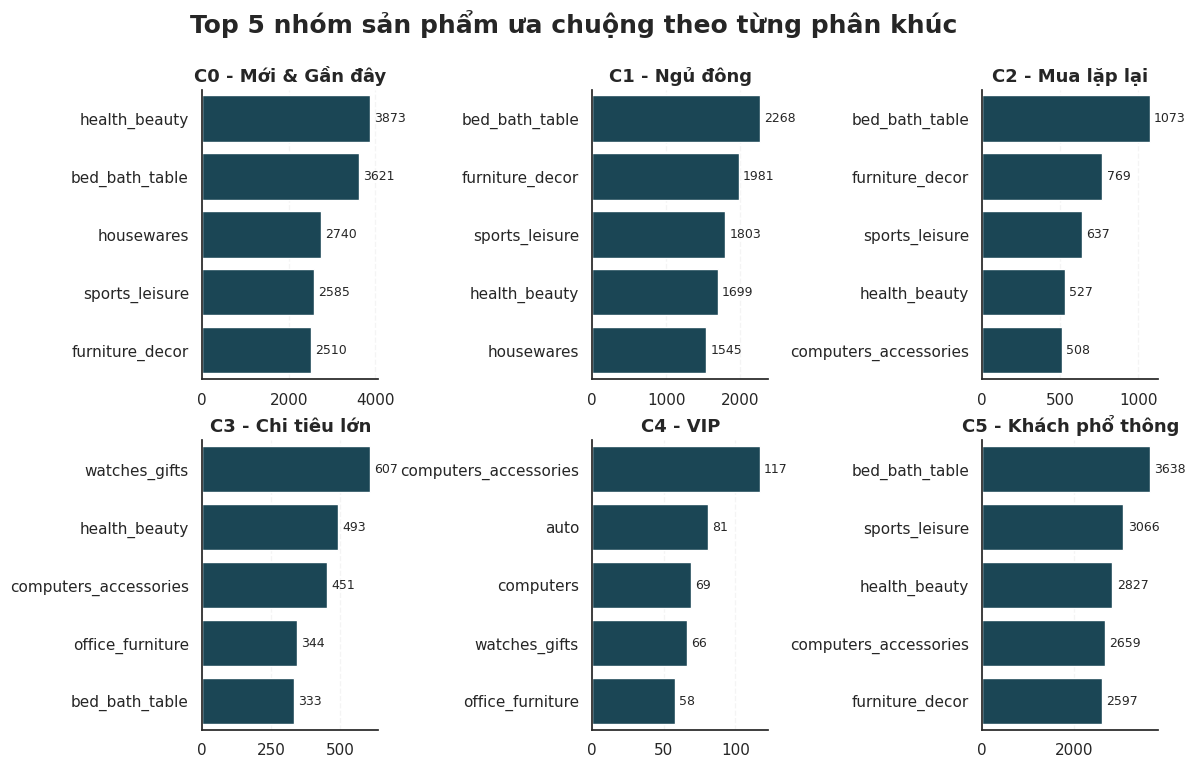

In [86]:
# Map segment_label từ cluster_profile
top5 = (
    cluster_category
    .assign(segment_name=
            cluster_category['clusters']
            .map(cluster_to_label))
    .sort_values(['clusters', 'orders'],
                 ascending=[True, False])
    .groupby('segment_name')
    .head(5))

# Thứ tự C0 → C5 lấy từ cluster_profile
segment_order = (
    cluster_profile
    .sort_values('segment_code')['segment_label']
    .tolist())

top5['segment_name'] = pd.Categorical(
    top5['segment_name'],
    categories=segment_order,
    ordered=True)

# Plot
sns.set_style("white")
g = sns.FacetGrid(
    top5,
    col='segment_name',
    col_wrap=3,
    height=4,
    sharex=False,
    sharey=False
)
g.map_dataframe(
    sns.barplot,
    x='orders',
    y='product_category_name_english',
    color=MAIN_COLOR
)
for ax in g.axes.flatten():
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', linestyle='--', alpha=0.2)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f', padding=3, fontsize=9)

g.set_titles("{col_name}", size=13, weight='bold')
plt.subplots_adjust(top=0.88)
g.fig.suptitle(
    'Top 5 nhóm sản phẩm ưa chuộng theo từng phân khúc',
    fontsize=18, fontweight='bold'
)
plt.show()